**1. Impor Library: Menyiapkan Kotak Perkakas**

Langkah pertama adalah memuat semua "perkakas" atau library Python yang kita butuhkan untuk analisis data, pembangunan model, dan evaluasi.

In [1]:
# Impor Library Esensial
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split # Meskipun slicing manual dipakai
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    mean_squared_error
)
import joblib
import os
import math
try:
    import pandas_ta as ta
except ModuleNotFoundError:
    print("ERROR: pandas_ta tidak ditemukan. Mohon install: pip install pandas_ta")
    PANDAS_TA_AVAILABLE = False
else:
    PANDAS_TA_AVAILABLE = True

**import numpy as np**: Mengimpor pustaka NumPy untuk operasi numerik, terutama array multidimensi yang efisien.

**import pandas as pd**: Mengimpor pustaka Pandas untuk manipulasi dan analisis data tabular menggunakan struktur data DataFrame.

**import yfinance as yf**: Mengimpor pustaka yfinance untuk mengunduh data pasar finansial historis dari Yahoo Finance.

**import matplotlib.pyplot as plt**: Mengimpor modul pyplot dari Matplotlib untuk membuat visualisasi data (grafik, plot).

**from sklearn.preprocessing import MinMaxScaler**: Mengimpor kelas MinMaxScaler dari Scikit-learn untuk melakukan penskalaan fitur (normalisasi) ke rentang tertentu (default [0, 1]).

**from sklearn.model_selection import train_test_split**: Mengimpor fungsi train_test_split untuk membagi data menjadi set pelatihan dan pengujian secara acak (meskipun skrip ini akhirnya menggunakan pembagian manual berdasarkan waktu).

**from sklearn.linear_model import LogisticRegression, LinearRegression**: Mengimpor kelas model LogisticRegression (untuk klasifikasi) dan LinearRegression (untuk regresi).

**from sklearn.ensemble import RandomForestClassifier**: Mengimpor kelas model RandomForestClassifier (algoritma ensemble berbasis pohon keputusan untuk klasifikasi).

**from sklearn.metrics import (...)**: Mengimpor berbagai fungsi dari Scikit-learn untuk mengevaluasi kinerja model:

+ *classification_report*: Menampilkan metrik presisi, recall, f1-score, support per kelas.

+ *confusion_matrix*: Menghitung matriks konfusi (TP, TN, FP, FN).

+ *accuracy_score*: Menghitung akurasi model klasifikasi.

+ *roc_auc_score*: Menghitung Area Under the ROC Curve (AUC).

+ *roc_curve* : Menghitung titik-titik untuk plot kurva ROC.

+ *ConfusionMatrixDisplay*: Untuk memvisualisasikan matriks konfusi.

+ *mean_squared_error*: Menghitung Mean Squared Error (MSE) untuk evaluasi regresi.

**import joblib**: Mengimpor pustaka Joblib, sering digunakan untuk menyimpan (serialisasi) dan memuat model Scikit-learn yang sudah dilatih.

**import os**: Mengimpor modul OS untuk berinteraksi dengan sistem operasi, seperti memeriksa keberadaan file atau menghapus file.

**import math**: Mengimpor modul math untuk fungsi matematika dasar (tidak terlalu digunakan di bagian inti model ini).

**try...except...else untuk pandas_ta**: Blok ini mencoba mengimpor pustaka pandas_ta. Jika berhasil, PANDAS_TA_AVAILABLE diatur ke True. Jika gagal (modul tidak terinstal), pesan error dicetak dan variabel diatur ke False. Ini memungkinkan skrip berjalan meskipun pandas_ta tidak ada, meskipun beberapa fitur tidak akan dihitung.

**2. Konfigurasi Dasar dan Nama File: Menentukan Bahan dan Label**

Di sini kita tentukan bahan utama (aset crypto), aturan dasar, daftar fitur yang akan kita pakai, dan nama untuk menyimpan hasil akhir.

In [2]:
# --- Konfigurasi Dasar ---
TICKER = 'BTC-USD'
TIME_STEP = 60 
TRAIN_SPLIT_RATIO = 0.8 

# --- Fitur Input (SEHARUSNYA 16 FITUR) ---
FEATURE_COLUMNS_INPUT = [
    'BBB_20_2.0', 'CMF_20', 'Close', 'Close_Diff_lag1', 
    'Close_Diff_lag2', 'Close_Diff_lag3', 'MACD_12_26_9', 
    'OBV', 'RSI_14', 'SMA_20', 'STOCHd_14_3_3', 'STOCHk_14_3_3', 
    'Volume', 'Volume_lag1', 'Volume_lag2', 'Volume_lag3'
]
N_FEATURES_INPUT = len(FEATURE_COLUMNS_INPUT) # Harus 16
# --------------------------------------------------

# --- Nama File Output ---
LOGREG_MODEL_SAVE_PATH = f'logreg_clf_{TICKER}_advTA_model.pkl'
RF_MODEL_SAVE_PATH = f'rf_clf_{TICKER}_advTA_model.pkl'
LINREG_MODEL_SAVE_PATH = f'linreg_reg_{TICKER}_advTA_model.pkl' 
SCALER_X_SAVE_PATH = f'scaler_X_classic_combined_{TICKER}_advTA.pkl' 
SCALER_Y_REG_SAVE_PATH = f'scaler_y_classic_reg_{TICKER}_advTA.pkl' 

**Penjelasan:** 

Blok ini menetapkan variabel-variabel yang akan digunakan di seluruh script. TICKER menentukan aset target. TRAIN_SPLIT_RATIO mengatur pembagian data. FEATURE_COLUMNS_INPUT adalah daftar kunci yang berisi nama persis dari 16 fitur yang akan kita rekayasa dan gunakan sebagai input model. N_FEATURES_INPUT menyimpan jumlahnya. Nama file output dibuat secara dinamis menggunakan f-string berdasarkan TICKER.

Menetapkan variabel konfigurasi utama:

+ **TICKER**: Simbol aset yang akan dianalisis (Bitcoin vs USD).

+ **TIME_STEP**: Biasanya untuk model sekuensial seperti LSTM, tampaknya tidak relevan untuk model klasik ini.

+ **TRAIN_SPLIT_RATIO**: Proporsi data yang digunakan untuk pelatihan (80%).

+ **FEATURE_COLUMNS_INPUT**: Daftar penting yang berisi nama-nama dari 16 fitur teknikal dan harga yang akan digunakan sebagai input untuk model.

+ **N_FEATURES_INPUT**: Jumlah fitur yang diharapkan (16).
Menentukan nama file (menggunakan f-string) untuk menyimpan model dan scaler yang sudah dilatih/di-fit. Nama file dibuat dinamis berdasarkan TICKER.

**3. Membersihkan File Lama (Opsional):**

Sebelum memulai, kita hapus dulu file model atau scaler lama yang mungkin ada agar tidak tertukar.

In [3]:
# --- Hapus file lama ---
# ... (kode hapus file sama) ...
if os.path.exists(LOGREG_MODEL_SAVE_PATH): os.remove(LOGREG_MODEL_SAVE_PATH)
if os.path.exists(RF_MODEL_SAVE_PATH): os.remove(RF_MODEL_SAVE_PATH)
if os.path.exists(LINREG_MODEL_SAVE_PATH): os.remove(LINREG_MODEL_SAVE_PATH) 
if os.path.exists(SCALER_X_SAVE_PATH): os.remove(SCALER_X_SAVE_PATH)
if os.path.exists(SCALER_Y_REG_SAVE_PATH): os.remove(SCALER_Y_REG_SAVE_PATH) 
print("File model/scaler klasik lama (jika ada) telah dihapus.")

File model/scaler klasik lama (jika ada) telah dihapus.


**Penjelasan:** 

Kode ini menggunakan os.path.exists untuk mengecek apakah file dengan nama tersebut ada, dan os.remove untuk menghapusnya jika ditemukan. Ini memastikan file yang disimpan nanti adalah hasil eksekusi yang baru.

+ Menggunakan modul os untuk mengecek (os.path.exists) apakah file model/scaler dari eksekusi sebelumnya ada.

+ Jika ada, file tersebut dihapus (os.remove) untuk memastikan file yang disimpan nanti adalah hasil dari eksekusi skrip saat ini.

**4. Ambil Data & Persiapan Awal: Mendapatkan Bahan Baku**

Kita unduh data harga historis dan pastikan format kolomnya benar.

In [4]:
# --- Step 1: Ambil Data & Feature Engineering ---
# ... (Kode ambil data, penanganan kolom, hitung TA, hitung Lag sama persis seperti v2) ...
print(f"Mengambil data yfinance untuk: {TICKER}...")
df = yf.download(TICKER, start='2017-01-01', end='2024-01-01')
print("Data diambil.")
if df.empty: raise ValueError(f"Gagal mengambil data untuk {TICKER}.")
print("\n--- Struktur Kolom Asli ---")
print("Tipe Kolom:", type(df.columns)); print("Nilai Kolom (sampel):", df.columns[:6].tolist())
print("---------------------------\n")
df_processed_temp = df.copy()
if isinstance(df_processed_temp.columns, pd.MultiIndex):
    print("MultiIndex kolom. Meratakan..."); 
    try: 
        df_processed_temp.columns = df_processed_temp.columns.get_level_values(0).str.title()
        df_processed_temp = df_processed_temp.loc[:, ~df_processed_temp.columns.duplicated()]
        print(f"Kolom setelah perataan: {df_processed_temp.columns.tolist()}")
    except Exception as e: raise ValueError(f"Gagal meratakan MultiIndex: {e}.")
else: 
    print("Menstandarkan nama kolom ke Title Case...")
    df_processed_temp.columns = [str(col).title() for col in df_processed_temp.columns]
    print(f"Kolom setelah standarisasi: {df_processed_temp.columns.tolist()}")
high_col_name, low_col_name, close_col_name, volume_col_name = 'High', 'Low', 'Close', 'Volume' 
required_cols = [high_col_name, low_col_name, close_col_name, volume_col_name]
missing_req = [col for col in required_cols if col not in df_processed_temp.columns]
if missing_req: raise KeyError(f"Kolom standar hilang: {missing_req}.") 
print(f"Kolom HLCV standar yang digunakan: {required_cols}"); df = df_processed_temp

Mengambil data yfinance untuk: BTC-USD...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Data diambil.

--- Struktur Kolom Asli ---
Tipe Kolom: <class 'pandas.core.indexes.multi.MultiIndex'>
Nilai Kolom (sampel): [('Close', 'BTC-USD'), ('High', 'BTC-USD'), ('Low', 'BTC-USD'), ('Open', 'BTC-USD'), ('Volume', 'BTC-USD')]
---------------------------

MultiIndex kolom. Meratakan...
Kolom setelah perataan: ['Close', 'High', 'Low', 'Open', 'Volume']
Kolom HLCV standar yang digunakan: ['High', 'Low', 'Close', 'Volume']


**Penjelasan:** 

yf.download mengambil data OHLCV (Open, High, Low, Close, Volume) dari Yahoo Finance untuk rentang waktu yang ditentukan dan menyimpannya dalam tabel df. Bagian penanganan kolom (diringkas di sini) penting untuk memastikan data siap diolah lebih lanjut.

**yf.download(...)**: Mengunduh data harga historis (Open, High, Low, Close, Volume, Adj Close) untuk TICKER dalam rentang tanggal yang ditentukan dari Yahoo Finance dan menyimpannya ke DataFrame Pandas df.

**Pengecekan df.empty**: Memastikan data berhasil diunduh.

**Penanganan Kolom**: Data dari yfinance kadang memiliki MultiIndex pada kolom jika beberapa ticker diunduh. Kode ini mengecek tipe kolom:

+ Jika MultiIndex, kolom diratakan (get_level_values(0)) dan diubah ke Title Case (.str.title()). Duplikat kolom (jika ada setelah perataan) dihapus.
+ Jika bukan MultiIndex, nama kolom langsung diubah ke Title Case.

**Pengecekan Kolom Wajib**: Memastikan kolom 'High', 'Low', 'Close', 'Volume' ada setelah pemrosesan nama kolom.

**df = df_processed_temp**: DataFrame asli df diperbarui dengan DataFrame yang nama kolomnya sudah diproses.

**5. Rekayasa Fitur (Feature Engineering): Membuat Fitur Prediktif**

Dari data dasar OHLCV, kita hitung fitur-fitur tambahan yang diharapkan membantu model memahami pasar.

In [5]:
print("Menghitung fitur teknikal dasar..."); sma_col_name, rsi_col_name, macd_col_name = 'SMA_20', 'RSI_14', 'MACD_12_26_9'
df[sma_col_name] = df[close_col_name].rolling(window=20).mean(); 
if PANDAS_TA_AVAILABLE:
    try: 
        df.ta.rsi(close=df[close_col_name], length=14, col_names=(rsi_col_name,), append=True); 
        df.ta.macd(close=df[close_col_name], col_names=(macd_col_name, f'MACDh_12_26_9', f'MACDs_12_26_9'), append=True); 
        print("Fitur dasar TA dihitung.")
        print("Menghitung fitur teknikal lanjutan..."); 
        adv_ta_to_calculate = {'atr': {'high': df[high_col_name], 'low': df[low_col_name], 'close': df[close_col_name], 'length': 14, 'col_names':'ATR_14'}, 'bbands': {'close': df[close_col_name], 'length': 20, 'std': 2, 'col_names': ('BBL_20_2.0', 'BBM_20_2.0', 'BBU_20_2.0', 'BBB_20_2.0', 'BBP_20_2.0')}, 'stoch': {'high': df[high_col_name], 'low': df[low_col_name], 'close': df[close_col_name], 'k': 14, 'd': 3, 'smooth_k': 3, 'col_names': ('STOCHk_14_3_3', 'STOCHd_14_3_3')}, 'obv': {'close': df[close_col_name], 'volume': df[volume_col_name], 'col_names':'OBV'}, 'cmf': {'high': df[high_col_name], 'low': df[low_col_name], 'close': df[close_col_name], 'volume': df[volume_col_name], 'length': 20, 'col_names':'CMF_20'}}
        for func_name, params in adv_ta_to_calculate.items():
             try: getattr(df.ta, func_name)(**params, append=True);
             except Exception as ta_err: print(f" Warning: Gagal hitung TA ({func_name}): {ta_err}"); continue
        print("Fitur teknikal lanjutan dihitung (jika berhasil).")
    except Exception as e: print(f"Warning: Error besar saat menghitung fitur TA: {e}.")
else: print("pandas_ta tidak tersedia.")
print("Menghitung fitur lag..."); target_diff_temp_col = 'Close_Diff_Temp'; df[target_diff_temp_col] = df[close_col_name].diff()
lags_to_add = [1, 2, 3]
for lag in lags_to_add: lag_col_diff = f'Close_Diff_lag{lag}'; df[lag_col_diff] = df[target_diff_temp_col].shift(lag); lag_col_vol = f'{volume_col_name}_lag{lag}'; df[lag_col_vol] = df[volume_col_name].shift(lag); 
df = df.drop(columns=[target_diff_temp_col], errors='ignore'); print(f"Fitur lag dihitung.")

Menghitung fitur teknikal dasar...
Fitur dasar TA dihitung.
Menghitung fitur teknikal lanjutan...
Fitur teknikal lanjutan dihitung (jika berhasil).
Menghitung fitur lag...
Fitur lag dihitung.


**Penjelasan**: 

Ini adalah inti dari pembuatan. Kita hitung rata-rata bergerak (SMA). Jika bisa, kita pakai pandas_ta untuk hitung otomatis banyak indikator populer seperti RSI, MACD, Bollinger Bands, dll. Kita juga buat fitur "lag" dengan .diff().shift(lag) untuk memberi tahu model berapa perubahan harga kemarin, lusa, dst., serta berapa volume perdagangan pada hari-hari sebelumnya.

**Indikator Teknikal Dasar**:

+ **df[close_col_name].rolling(window=20).mean()**: Menghitung Simple Moving Average (SMA) 20 hari untuk harga penutupan.

**Indikator Teknikal Lanjutan (jika pandas_ta tersedia)**:

+ **df.ta.rsi(...), df.ta.macd(...)**: Menggunakan pandas_ta untuk menghitung RSI (Relative Strength Index) dan MACD (Moving Average Convergence Divergence). append=True menambahkan hasilnya sebagai kolom baru ke DataFrame df.

+ **Loop adv_ta_to_calculate**: Menghitung indikator teknikal tambahan (ATR, Bollinger Bands, Stochastic, OBV, CMF) secara dinamis. getattr(df.ta, func_name) mendapatkan fungsi TA dari pandas_ta berdasarkan nama, dan (**params, append=True) memanggil fungsi tersebut dengan parameter yang ditentukan dalam dictionary.

**Fitur Lag (Keterlambatan)**:
+ **df[close_col_name].diff()**: Menghitung perbedaan harga penutupan antara hari ini dan hari sebelumnya. Disimpan sementara di Close_Diff_Temp.

+ **Loop lags_to_add: Untuk setiap lag (1, 2, 3)**:

    + **df[target_diff_temp_col].shift(lag)**: Menggeser nilai perbedaan harga ke belakang sejauh lag hari. Ini memberikan informasi tentang perubahan harga 1 hari lalu, 2 hari lalu, dst. sebagai fitur untuk hari ini.

    + **df[volume_col_name].shift(lag)**: Menggeser nilai Volume ke belakang sejauh lag hari, memberikan informasi volume perdagangan hari-hari sebelumnya.

+ **df.drop(...)**: Menghapus kolom sementara Close_Diff_Temp.

**6. Filter Fitur Input FINAL:**

Memastikan hanya 16 fitur yang kita pilih di awal yang akan digunakan.

In [6]:
# === Filter fitur input FINAL (berdasarkan definisi FEATURE_COLUMNS_INPUT di atas) ===
feature_columns_input_final = [f for f in FEATURE_COLUMNS_INPUT if f in df.columns] # Filter berdasarkan list 16 fitur
print(f"Fitur input FINAL yang akan digunakan ({len(feature_columns_input_final)}): {feature_columns_input_final}"); 
n_features_input_check = len(feature_columns_input_final)
if n_features_input_check != N_FEATURES_INPUT: print(f"WARNING: Jumlah fitur final ({n_features_input_check}) berbeda dari yang diharapkan ({N_FEATURES_INPUT})!")


Fitur input FINAL yang akan digunakan (16): ['BBB_20_2.0', 'CMF_20', 'Close', 'Close_Diff_lag1', 'Close_Diff_lag2', 'Close_Diff_lag3', 'MACD_12_26_9', 'OBV', 'RSI_14', 'SMA_20', 'STOCHd_14_3_3', 'STOCHk_14_3_3', 'Volume', 'Volume_lag1', 'Volume_lag2', 'Volume_lag3']


**Penjelasan:**
 
Setelah membuat banyak fitur, kode ini memastikan kita hanya mengambil 16 fitur yang namanya ada di daftar FEATURE_COLUMNS_INPUT kita.

+ Memfilter kolom-kolom di DataFrame df untuk memastikan hanya kolom yang namanya ada dalam list FEATURE_COLUMNS_INPUT (yang didefinisikan di awal sebagai 16 fitur target) yang akan digunakan sebagai fitur input (X). Ini penting jika proses rekayasa fitur menghasilkan kolom tambahan yang tidak diinginkan sebagai input model.

+ **Pengecekan len(feature_columns_input_final)**: Memastikan jumlah fitur final sesuai dengan yang diharapkan (16).

**7. Kreasi Variabel Target:**

Menentukan apa yang akan diprediksi oleh model.

In [7]:
# === Hitung Target ===
target_clf_column = 'Direction' 
target_reg_column = 'Close_Diff' 
df[target_clf_column] = (df[close_col_name].diff() >= 0).astype(int)
df[target_reg_column] = df[close_col_name].diff().fillna(0) 
print(f"Target klasifikasi '{target_clf_column}' dihitung.")
print(f"Target regresi '{target_reg_column}' dihitung.")


Target klasifikasi 'Direction' dihitung.
Target regresi 'Close_Diff' dihitung.


**Penjelasan:** 

Kita buat dua target: Direction (angka 0 atau 1) untuk model klasifikasi, dan Close_Diff (angka perubahan harga) untuk model regresi.

+ Mendefinisikan nama kolom untuk target.

+ Target Klasifikasi (Direction):

    + **df[close_col_name].diff() >= 0**: Menghitung perbedaan harga Close, lalu mengecek apakah perubahannya non-negatif (harga naik atau sama). Hasilnya adalah boolean (True/False).

    + **.astype(int)**: Mengkonversi True menjadi 1 (harga naik/sama) dan False menjadi 0 (harga turun). Ini adalah target untuk model LR dan RF.

+ Target Regresi (Close_Diff):

    + **df[close_col_name].diff()**: Menghitung perbedaan harga Close (nilai numerik perubahan).
    
    + **.fillna(0)**: Mengisi nilai NaN (biasanya pada baris pertama karena tidak ada hari sebelumnya) dengan 0. Ini adalah target untuk model Linear Regression.

**8. Preprocessing Akhir: Drop NA, Split, Scale:**

Membersihkan, membagi, dan menyamakan skala data.

In [8]:
# --- Drop NA ---
original_len = len(df); 
# Kolom yang dibutuhkan sebelum dropna: fitur input final + target + close asli
columns_to_keep_before_dropna = feature_columns_input_final + [target_clf_column, target_reg_column, close_col_name] 
columns_to_keep_before_dropna = list(set(columns_to_keep_before_dropna)) # Pastikan unik
columns_to_keep_before_dropna = [c for c in columns_to_keep_before_dropna if c in df.columns] 
df_processed = df[columns_to_keep_before_dropna].dropna()
print(f"Menghapus {original_len - len(df_processed)} baris karena NaN.");
if len(df_processed) < 20: raise ValueError(f"Data tidak cukup ({len(df_processed)} baris) setelah dropna.") 
print(f"Shape data setelah dropna: {df_processed.shape}")

# --- Step 2: Pisahkan Fitur (X) dan Target (y_clf, y_reg) ---
### PERBAIKAN FINAL: Gunakan feature_columns_input_final yang sudah difilter ###
X_all = df_processed[feature_columns_input_final] # Gunakan list ini (seharusnya 16 fitur)
y_clf_all = df_processed[target_clf_column]
y_reg_all = df_processed[target_reg_column] 
print(f"Pemisahan data: X shape: {X_all.shape}, y_clf shape: {y_clf_all.shape}, y_reg shape: {y_reg_all.shape}") 
# ^^^ Verifikasi X shape di sini! HARUSNYA (..., 16) ^^^

# --- Step 3: Split Train-Test ---
split_idx = int(len(X_all) * TRAIN_SPLIT_RATIO)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_clf_train, y_clf_test = y_clf_all[:split_idx], y_clf_all[split_idx:]
y_reg_train, y_reg_test = y_reg_all[:split_idx], y_reg_all[split_idx:] 

print(f"Data split. X_train: {X_train.shape}, X_test: {X_test.shape}") # Verifikasi shape X_train dan X_test
print(f"Distribusi target CLF (Train): {np.bincount(y_clf_train)}")
print(f"Distribusi target CLF (Test): {np.bincount(y_clf_test)}")

# --- Step 4: Scaling Fitur Input (X) dan Target Regresi (y_reg) ---
print("Melakukan scaling fitur input (X)...")
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train) # Fit & Transform data training (16 fitur)
X_test_scaled = scaler_X.transform(X_test)     # Hanya Transform data test (16 fitur)
print("Scaling fitur input selesai.")

print("Melakukan scaling target regresi (y_reg)...")
scaler_y_reg = MinMaxScaler()
y_train_diff_scaled = scaler_y_reg.fit_transform(y_reg_train.values.reshape(-1, 1))
y_test_diff_scaled = scaler_y_reg.transform(y_reg_test.values.reshape(-1, 1)) 
print("Scaling target regresi selesai.")


Menghapus 25 baris karena NaN.
Shape data setelah dropna: (2531, 18)
Pemisahan data: X shape: (2531, 16), y_clf shape: (2531,), y_reg shape: (2531,)
Data split. X_train: (2024, 16), X_test: (507, 16)
Distribusi target CLF (Train): [ 938 1086]
Distribusi target CLF (Test): [262 245]
Melakukan scaling fitur input (X)...
Scaling fitur input selesai.
Melakukan scaling target regresi (y_reg)...
Scaling target regresi selesai.


**Penjelasan:** 

.dropna() membersihkan baris kosong. Data lalu dipisah menjadi fitur (X) dan target (y). Slicing [:split_idx] dan [split_idx:] membagi data secara kronologis menjadi 80% training dan 20% test. MinMaxScaler digunakan untuk membuat semua nilai fitur (X) dan target perubahan harga (y_reg) berada antara 0 dan 1. Proses fit_transform pada data training mempelajari skala data tersebut, lalu transform pada data test menerapkan skala yang sama tanpa "melihat" data test (mencegah data leakage).

+ **Drop NA**:

    + Perhitungan indikator teknikal (SMA, RSI, dll.) dan fitur lag menghasilkan nilai NaN (Not a Number) di awal data.
    
    + **columns_to_keep_before_dropna**: Memastikan hanya kolom fitur input final, kolom target, dan kolom 'Close' asli yang dipertimbangkan saat menghapus baris NaN.
    
    + **df[...].dropna()**: Menghapus semua baris yang mengandung setidaknya satu nilai NaN pada kolom-kolom yang dipilih. Hasilnya disimpan di df_processed.

+ **Pemisahan Fitur dan Target**:

    + **X_all**: Memilih kolom fitur (yang sudah difilter di Cell 17) dari df_processed.

    + **y_clf_all, y_reg_all**: Memilih kolom target klasifikasi dan regresi.

+ **Split Train-Test (Manual/Kronologis)**:

    + **split_idx**: Menghitung indeks baris yang memisahkan data train dan test berdasarkan TRAIN_SPLIT_RATIO.
    
    + **Slicing [:split_idx]**:  digunakan untuk mengambil data train (data awal hingga indeks split_idx).
    
    + **Slicing [split_idx:]** digunakan untuk mengambil data test (data dari indeks split_idx hingga akhir). Ini adalah pembagian kronologis, umum untuk data time series, di mana model dilatih pada data masa lalu dan diuji pada data masa depan.

+ **Scaling (Penskalaan Fitur dan Target Regresi)** :

    + **scaler_X** = MinMaxScaler(): Membuat objek scaler untuk fitur input (X).

    + **scaler_X.fit_transform(X_train)**: Mempelajari rentang nilai minimum dan maksimum dari data latih (X_train) dan kemudian mentransformasikannya ke rentang [0, 1]. Hasilnya X_train_scaled.
    
    + **scaler_X.transform(X_test)**: Hanya mentransformasi data uji (X_test) menggunakan rentang min/max yang sudah dipelajari dari data latih. Ini penting untuk mencegah data leakage (informasi dari data uji "bocor" ke proses pelatihan). Hasilnya X_test_scaled.
    
    + **scaler_y_reg = MinMaxScaler()**: Membuat objek scaler terpisah untuk target regresi (y_reg).

    + **fit_transform(y_reg_train.values.reshape(-1, 1))**: Melakukan hal yang sama seperti pada X_train untuk target regresi latih (y_reg_train). .values.reshape(-1, 1) diperlukan karena scaler mengharapkan input 2D.
    
    + **transform(y_reg_test.values.reshape(-1, 1))**: Menskalakan target regresi uji menggunakan parameter dari target regresi latih.

**9. Latih & Evaluasi Model Klasifikasi (LR & RF)**:

Membuat dan menguji model tebak arah.


--- Melatih Model Logistic Regression ---
Training Logistic Regression selesai.

--- Evaluasi Logistic Regression (Test Set) ---
Akurasi Logistic Regression: 0.6844
AUC Score Logistic Regression: 0.7491

Laporan Klasifikasi (Logistic Regression):
               precision    recall  f1-score   support

Down/Same(0)       0.76      0.58      0.65       262
       Up(1)       0.64      0.80      0.71       245

    accuracy                           0.68       507
   macro avg       0.70      0.69      0.68       507
weighted avg       0.70      0.68      0.68       507


Confusion Matrix (Logistic Regression):
 [[151 111]
 [ 49 196]]


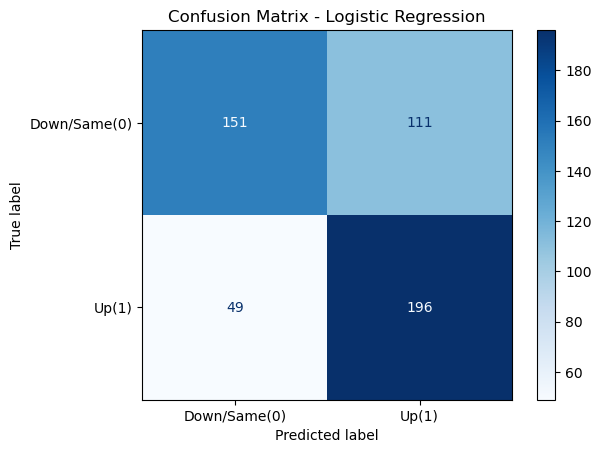


--- Melatih Model Random Forest Classifier ---
Training Random Forest selesai.

--- Evaluasi Random Forest Classifier (Test Set) ---
Akurasi Random Forest: 0.6706
AUC Score Random Forest: 0.7580

Laporan Klasifikasi (Random Forest):
               precision    recall  f1-score   support

Down/Same(0)       0.73      0.58      0.64       262
       Up(1)       0.63      0.77      0.69       245

    accuracy                           0.67       507
   macro avg       0.68      0.67      0.67       507
weighted avg       0.68      0.67      0.67       507


Confusion Matrix (Random Forest):
 [[151 111]
 [ 56 189]]


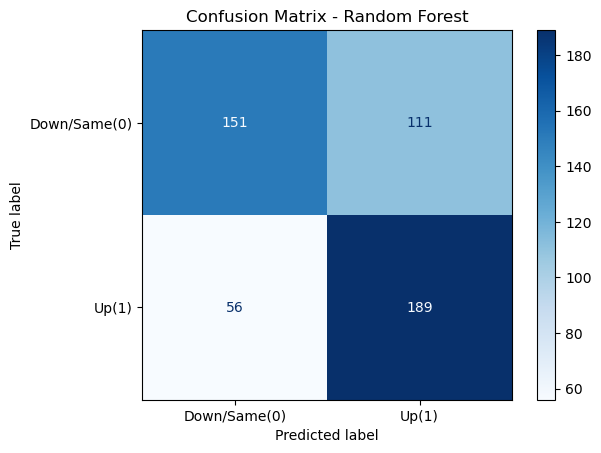

In [9]:
# --- Step 5 & 6: Logistic Regression (Klasifikasi) ---
# ... (Kode sama) ...
print("\n--- Melatih Model Logistic Regression ---")
log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000) 
log_reg.fit(X_train_scaled, y_clf_train) 
print("Training Logistic Regression selesai.")
print("\n--- Evaluasi Logistic Regression (Test Set) ---")
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_proba_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1] 
accuracy_lr = accuracy_score(y_clf_test, y_pred_log_reg) 
report_lr = classification_report(y_clf_test, y_pred_log_reg, target_names=['Down/Same(0)', 'Up(1)'])
conf_matrix_lr = confusion_matrix(y_clf_test, y_pred_log_reg)
try: auc_score_lr = roc_auc_score(y_clf_test, y_proba_log_reg)
except ValueError as e: print(f"Warning LR: Tidak bisa hitung AUC: {e}"); auc_score_lr = np.nan
print(f"Akurasi Logistic Regression: {accuracy_lr:.4f}"); print(f"AUC Score Logistic Regression: {auc_score_lr:.4f}")
print("\nLaporan Klasifikasi (Logistic Regression):\n", report_lr); print("\nConfusion Matrix (Logistic Regression):\n", conf_matrix_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_lr, display_labels=['Down/Same(0)', 'Up(1)']); disp_lr.plot(cmap=plt.cm.Blues); plt.title('Confusion Matrix - Logistic Regression'); plt.show()


# --- Step 7 & 8: Random Forest Classifier (Klasifikasi) ---
# ... (Kode sama) ...
print("\n--- Melatih Model Random Forest Classifier ---")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1) 
rf_clf.fit(X_train_scaled, y_clf_train) 
print("Training Random Forest selesai.")
print("\n--- Evaluasi Random Forest Classifier (Test Set) ---")
y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1] 
accuracy_rf = accuracy_score(y_clf_test, y_pred_rf) 
report_rf = classification_report(y_clf_test, y_pred_rf, target_names=['Down/Same(0)', 'Up(1)'])
conf_matrix_rf = confusion_matrix(y_clf_test, y_pred_rf)
try: auc_score_rf = roc_auc_score(y_clf_test, y_proba_rf)
except ValueError as e: print(f"Warning RF: Tidak bisa hitung AUC: {e}"); auc_score_rf = np.nan
print(f"Akurasi Random Forest: {accuracy_rf:.4f}"); print(f"AUC Score Random Forest: {auc_score_rf:.4f}")
print("\nLaporan Klasifikasi (Random Forest):\n", report_rf); print("\nConfusion Matrix (Random Forest):\n", conf_matrix_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=['Down/Same(0)', 'Up(1)']); disp_rf.plot(cmap=plt.cm.Blues); plt.title('Confusion Matrix - Random Forest'); plt.show()


**Penjelasan** :

Kita membuat objek model LR dan RF. Metode .fit() adalah proses trainingnya. Setelah dilatih, .predict() menghasilkan tebakan kelas (0 atau 1) dan .predict_proba() menghasilkan skor kemungkinan (antara 0 dan 1) untuk setiap kelas. Kita kemudian gunakan fungsi dari sklearn.metrics untuk membandingkan tebakan (y_pred...) dengan jawaban benar (y_clf_test) dan menghitung skor performa.

+ **Pelatihan Model**:

    + Membuat instance model:

        + **LogisticRegression(...)**: Dengan solver='liblinear' (baik untuk dataset kecil), random_state (untuk reproduktifitas), max_iter (jumlah iterasi maksimum).

        + **RandomForestClassifier(...)**: Dengan n_estimators=100 (jumlah pohon), random_state, class_weight='balanced' (menangani ketidakseimbangan kelas target jika ada), n_jobs=-1 (menggunakan semua core CPU untuk paralelisme).

    + **model.fit(X_train_scaled, y_clf_train)**: Melatih masing-masing model menggunakan data fitur latih yang sudah diskalakan (X_train_scaled) dan target klasifikasi latih (y_clf_train).

+ **Evaluasi Model pada Test Set**:

    + **model.predict(X_test_scaled)**: Menggunakan model yang sudah dilatih untuk membuat prediksi kelas (0 atau 1) pada data fitur uji yang sudah diskalakan.

    + **model.predict_proba(X_test_scaled)[:, 1]**: Menghasilkan probabilitas prediksi untuk setiap kelas (kolom 0 untuk kelas 0, kolom 1 untuk kelas 1). Slicing [:, 1] mengambil probabilitas untuk kelas positif (kelas 1, 'Up'). Ini digunakan untuk menghitung AUC.

    + **Perhitungan Metrik**: Menggunakan fungsi dari sklearn.metrics untuk menghitung akurasi, AUC, laporan klasifikasi (presisi, recall, F1), dan matriks konfusi dengan membandingkan y_clf_test (nilai sebenarnya) dan y_pred_... (prediksi model). Ada try-except untuk AUC jika terjadi error (misal, model hanya memprediksi satu kelas).

    + **Visualisasi**: ConfusionMatrixDisplay(...).plot(): Membuat plot matriks konfusi untuk visualisasi kinerja model.

**10. Latih & Evaluasi Model Regresi (LinReg)**:

Membuat dan menguji model tebak angka perubahan harga.


--- Melatih Model Linear Regression (Regresi) ---
Training Linear Regression selesai.

--- Evaluasi Linear Regression (Regresi - Test Set) ---
Shape y_pred_diff_unscaled_reg (1D): (507,)
Shape actual_close_prices_before_test_diff (1D): (507,)
Shape actual_target_close_prices_test (1D): (507,)
Shape y_pred_absolute_reg: (507,)
RMSE Linear Regression (pada harga absolut): 399.09
Membuat plot hasil backtest regresi (harga absolut)...


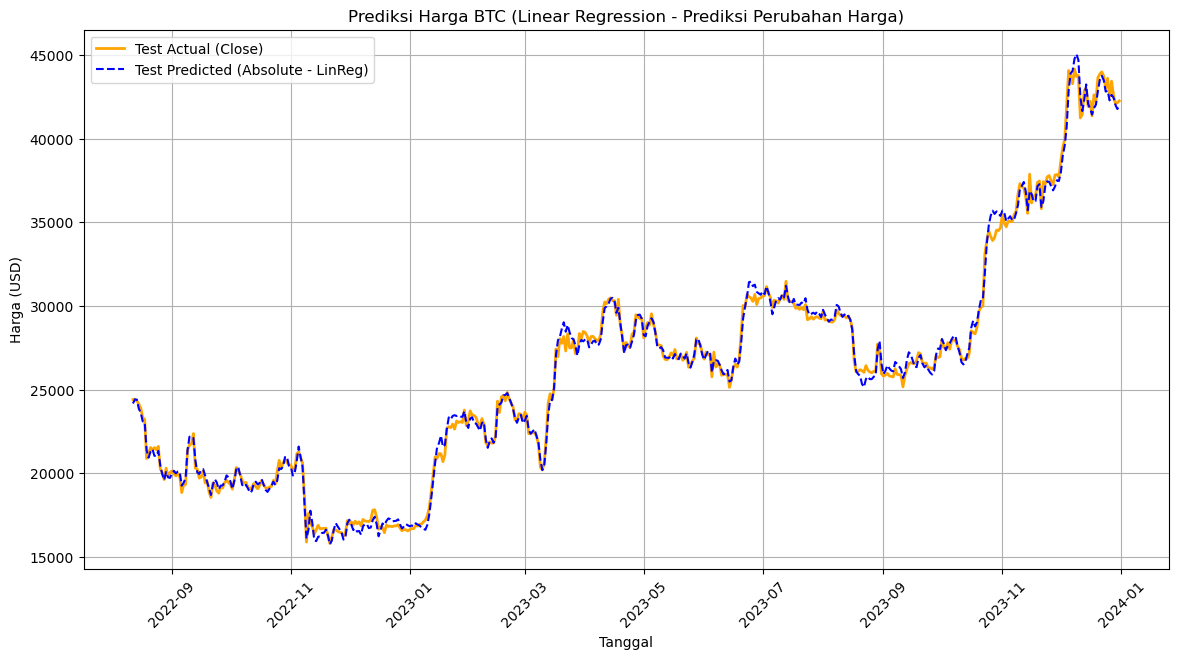

In [10]:
# --- Step 9: Latih Model Linear Regression (Regresi) ---
# ... (Kode sama) ...
print("\n--- Melatih Model Linear Regression (Regresi) ---")
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_diff_scaled.ravel()) 
print("Training Linear Regression selesai.")

# --- Step 10: Evaluasi Linear Regression (Regresi - Test Set) --- 
# ... (Kode evaluasi & plot sama, menggunakan slicing index eksplisit v2) ...
print("\n--- Evaluasi Linear Regression (Regresi - Test Set) ---")
y_pred_diff_scaled_reg = lin_reg.predict(X_test_scaled) 
y_pred_diff_unscaled_reg = scaler_y_reg.inverse_transform(y_pred_diff_scaled_reg.reshape(-1, 1)).flatten() 
n_test = len(X_test) 
actual_target_close_prices_test = df_processed['Close'].values[split_idx : split_idx + n_test].flatten() 
start_eval_idx = split_idx - 1; end_eval_idx = start_eval_idx + n_test
actual_close_prices_before_test_diff = df_processed['Close'].values[start_eval_idx : end_eval_idx].flatten() 
print(f"Shape y_pred_diff_unscaled_reg (1D): {y_pred_diff_unscaled_reg.shape}")
print(f"Shape actual_close_prices_before_test_diff (1D): {actual_close_prices_before_test_diff.shape}")
print(f"Shape actual_target_close_prices_test (1D): {actual_target_close_prices_test.shape}")
if len(actual_close_prices_before_test_diff) == len(y_pred_diff_unscaled_reg):
    y_pred_absolute_reg = actual_close_prices_before_test_diff + y_pred_diff_unscaled_reg
    print(f"Shape y_pred_absolute_reg: {y_pred_absolute_reg.shape}")
    if len(y_pred_absolute_reg) == len(actual_target_close_prices_test):
        try: rmse_reg = np.sqrt(mean_squared_error(actual_target_close_prices_test, y_pred_absolute_reg)); print(f'RMSE Linear Regression (pada harga absolut): {rmse_reg:.2f}')
        except ValueError as e: print(f"Error RMSE Regresi: {e}"); rmse_reg = float('nan')
    else: print("RMSE Regresi gagal: panjang target aktual tidak cocok."); rmse_reg = float('nan')
else: print("Rekonstruksi harga absolut gagal: panjang harga sebelum tidak cocok."); rmse_reg = float('nan'); y_pred_absolute_reg = np.array([]) 
print("Membuat plot hasil backtest regresi (harga absolut)..."); plt.figure(figsize=(14, 7))
test_dates_reg = df_processed.index[split_idx : split_idx + n_test] 
if len(test_dates_reg) == len(actual_target_close_prices_test):
    plt.plot(test_dates_reg, actual_target_close_prices_test, label='Test Actual (Close)', color='orange', linewidth=2)
    if len(y_pred_absolute_reg) == len(test_dates_reg): plt.plot(test_dates_reg, y_pred_absolute_reg, label='Test Predicted (Absolute - LinReg)', color='blue', linestyle='--', linewidth=1.5)
    plt.xlabel('Tanggal'); plt.xticks(rotation=45)
else:
    print("WARNING: Index tanggal test set regresi tidak cocok. Menggunakan index numerik.")
    plt.plot(np.arange(len(actual_target_close_prices_test)), actual_target_close_prices_test, label='Test Actual (Close)', color='orange', linewidth=2)
    if len(y_pred_absolute_reg) == len(actual_target_close_prices_test): plt.plot(np.arange(len(y_pred_absolute_reg)), y_pred_absolute_reg, label='Test Predicted (Absolute - LinReg)', color='blue', linestyle='--', linewidth=1.5)
    plt.xlabel('Index Waktu (Test Set)')
plt.title('Prediksi Harga BTC (Linear Regression - Prediksi Perubahan Harga)'); plt.ylabel('Harga (USD)'); plt.legend(); plt.grid(True); plt.show()

**Penjelasan:** 

Model LinReg dilatih untuk memprediksi y_train_diff_scaled. Saat evaluasi, prediksinya (y_pred_diff_scaled_reg) perlu dikembalikan ke skala dolar (inverse_transform). Kemudian, kita lakukan rekonstruksi: harga asli hari sebelumnya ditambah prediksi perubahan harga hari ini menghasilkan prediksi harga absolut untuk hari ini. RMSE dihitung antara prediksi absolut ini dan harga absolut sebenarnya.

+ **Pelatihan Model Regresi**:

    + **lin_reg** = LinearRegression(): Membuat instance model regresi linear.

    + **lin_reg.fit(X_train_scaled, y_train_diff_scaled.ravel())**: Melatih model menggunakan fitur latih (X_train_scaled) untuk memprediksi perubahan harga yang sudah diskalakan (y_train_diff_scaled). .ravel() mengubah y menjadi 1D array.

+ **Evaluasi Model Regresi8**:

    + **y_pred_diff_scaled_reg = lin_reg.predict(X_test_scaled)**: Membuat prediksi perubahan harga (masih dalam skala [0,1]) pada data uji.

    + **scaler_y_reg.inverse_transform(...)**: Mengembalikan prediksi perubahan harga dari skala [0,1] ke skala dolar asli. .flatten() mengubahnya jadi 1D array.

+ **Rekonstruksi Harga Absolut**: Ini adalah langkah penting karena model memprediksi perubahan harga, bukan harga absolut.

    + **actual_close_prices_before_test_diff**: Mengambil harga penutupan aktual untuk setiap hari sebelum hari yang diprediksi dalam set test. Slicing [start_eval_idx : end_eval_idx] mengambil data dari satu hari sebelum test set dimulai hingga satu hari sebelum test set berakhir.

    + **actual_target_close_prices_test**: Mengambil harga penutupan aktual selama periode test untuk perbandingan.

    + **y_pred_absolute_reg = actual_close_prices_before_test_diff + y_pred_diff_unscaled_reg**: Menjumlahkan harga aktual hari sebelumnya dengan prediksi perubahan harga untuk hari ini untuk mendapatkan prediksi harga absolut hari ini.

+ **RMSE: np.sqrt(mean_squared_error(...))**: Menghitung Root Mean Squared Error antara harga penutupan aktual (actual_target_close_prices_test) dan harga penutupan absolut yang diprediksi **(y_pred_absolute_reg)**. RMSE memberikan ukuran rata-rata error prediksi dalam unit dolar.

+ **Plot Backtest**: Memvisualisasikan perbandingan antara harga penutupan aktual selama periode test dengan harga absolut yang diprediksi oleh model regresi linear.

**11. Visualisasi Perbandingan & Penyimpanan:**

Membandingkan model klasifikasi dan menyimpan semua hasil.



Membuat plot ROC Curve (Perbandingan)...



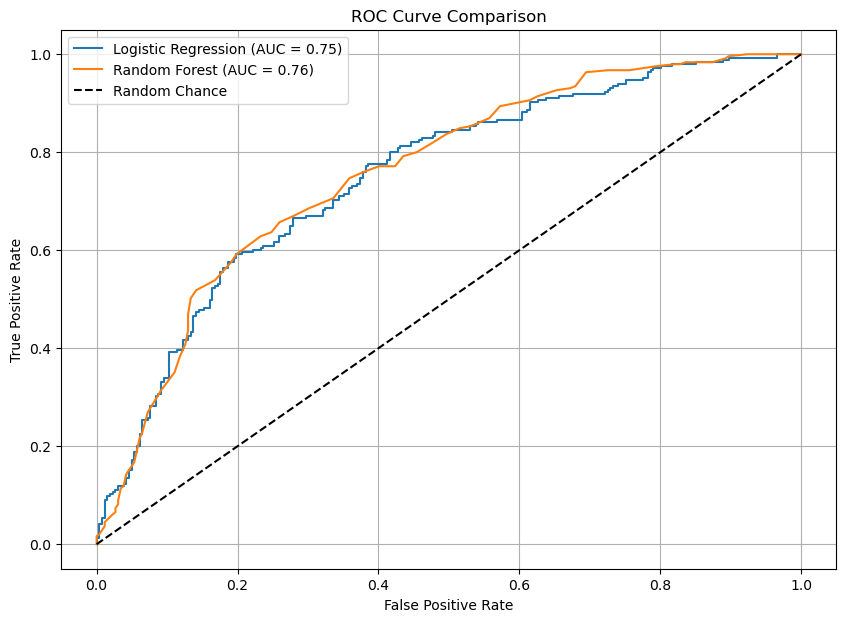


Menyimpan model dan scaler...
Model Logistic Regression, Random Forest, Linear Regression, Scaler X, dan Scaler Y (Regresi) berhasil disimpan.


In [11]:
# --- Step 11: Plot ROC Curve (Perbandingan) ---
# ... (Kode sama) ...
print("\nMembuat plot ROC Curve (Perbandingan)...\n")
fpr_lr, tpr_lr, _ = roc_curve(y_clf_test, y_proba_log_reg)
fpr_rf, tpr_rf, _ = roc_curve(y_clf_test, y_proba_rf)
plt.figure(figsize=(10, 7)); plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_score_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_score_rf:.2f})'); plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve Comparison'); plt.legend(); plt.grid(True); plt.show()

# --- Step 12: Simpan Model & Scaler --- 
print("\nMenyimpan model dan scaler...")
joblib.dump(log_reg, LOGREG_MODEL_SAVE_PATH)
joblib.dump(rf_clf, RF_MODEL_SAVE_PATH)
joblib.dump(lin_reg, LINREG_MODEL_SAVE_PATH) 
joblib.dump(scaler_X, SCALER_X_SAVE_PATH) # Scaler X dilatih dengan 16 fitur
joblib.dump(scaler_y_reg, SCALER_Y_REG_SAVE_PATH) 
print("Model Logistic Regression, Random Forest, Linear Regression, Scaler X, dan Scaler Y (Regresi) berhasil disimpan.")

# --- END OF FILE ---

Penjelasan: Kurva ROC membantu melihat model klasifikasi mana yang lebih baik secara visual. joblib.dump menyimpan semua komponen penting (model terlatih dan scaler) agar bisa digunakan lagi nanti tanpa perlu mengulang seluruh proses dari awal.

+ **Plot Kurva ROC**:

    + **roc_curve(...)**: Menghitung False Positive Rate (FPR) dan True Positive Rate (TPR) pada berbagai ambang batas klasifikasi untuk LR dan RF menggunakan probabilitas prediksi (y_proba_...).

    + **plt.plot(...)**: Membuat plot kurva ROC untuk kedua model pada grafik yang sama, menampilkan nilai AUC di legenda. Ini memungkinkan perbandingan visual langsung antara kinerja LR dan RF. Garis putus-putus diagonal merepresentasikan kinerja acak (AUC 0.5).

+ **Penyimpanan Model dan Scaler**:

    + **joblib.dump(objek, path)**: Menggunakan joblib untuk menyimpan objek model (LR, RF, LinReg) dan objek scaler (scaler_X, scaler_y_reg) yang sudah dilatih/di-fit ke dalam file biner (.pkl). Ini memungkinkan objek-objek ini dimuat kembali di lain waktu tanpa perlu melatih ulang model dari awal.